In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Zomato_Delivery_Cleaned.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (45584, 33)


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,...,City_was_missing,Multiple_deliveries_was_missing,Weather_was_missing,Traffic_was_missing,Festival_was_missing,Time_Orderd_Clean,Time_Order_picked_Clean,Order_DateTime,Pickup_DateTime,Pickup_Delay_Minutes
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,2022-02-12,21:55,...,0,0,0,0,0,21:55:00,22:10:00,2022-02-12 21:55:00.000000000,2022-02-12 22:10:00.000000000,15.0
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,2022-02-13,14:55,...,0,0,0,0,0,14:55:00,15:05:00,2022-02-13 14:55:00.000000000,2022-02-13 15:05:00.000000000,10.0
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,2022-03-04,17:30,...,0,0,0,0,0,17:30:00,17:40:00,2022-03-04 17:30:00.000000000,2022-03-04 17:40:00.000000000,10.0
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,2022-02-13,09:20,...,0,0,0,0,0,09:20:00,09:30:00,2022-02-13 09:20:00.000000000,2022-02-13 09:30:00.000000000,10.0
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,2022-02-14,19:50,...,0,0,0,0,0,19:50:00,20:05:00,2022-02-14 19:50:00.000000000,2022-02-14 20:05:00.000000000,15.0


In [3]:
invalid_age = df[
    (df["Delivery_person_Age"] < 18) |
    (df["Delivery_person_Age"] > 60)
]

print("Invalid Age Records:", len(invalid_age))

invalid_age["Delivery_person_Age"].value_counts().sort_index()

Invalid Age Records: 38


Delivery_person_Age
15.0    38
Name: count, dtype: int64

In [4]:
valid_age_median = df.loc[
    df["Delivery_person_Age"].between(18, 60),
    "Delivery_person_Age"
].median()

print("Valid Age Median:", valid_age_median)

Valid Age Median: 30.0


In [5]:
df.loc[
    ~df["Delivery_person_Age"].between(18, 60),
    "Delivery_person_Age"
] = valid_age_median

In [6]:
print(
    "Invalid Age Records:",
    ((df["Delivery_person_Age"] < 18) |
     (df["Delivery_person_Age"] > 60)).sum()
)

df["Delivery_person_Age"].describe()

Invalid Age Records: 0


count    45584.000000
mean        29.597030
std          5.680633
min         20.000000
25%         25.000000
50%         30.000000
75%         34.000000
max         50.000000
Name: Delivery_person_Age, dtype: float64

In [7]:
delivery_mean = df["Time_taken (min)"].mean()
delivery_median = df["Time_taken (min)"].median()
delivery_mode = df["Time_taken (min)"].mode()[0]

print("Mean Delivery Time:", round(delivery_mean, 2), "minutes")
print("Median Delivery Time:", delivery_median, "minutes")
print("Mode Delivery Time:", delivery_mode, "minutes")

df["Time_taken (min)"].describe()

Mean Delivery Time: 26.29 minutes
Median Delivery Time: 26.0 minutes
Mode Delivery Time: 26 minutes


count    45584.000000
mean        26.293963
std          9.384298
min         10.000000
25%         19.000000
50%         26.000000
75%         32.000000
max         54.000000
Name: Time_taken (min), dtype: float64

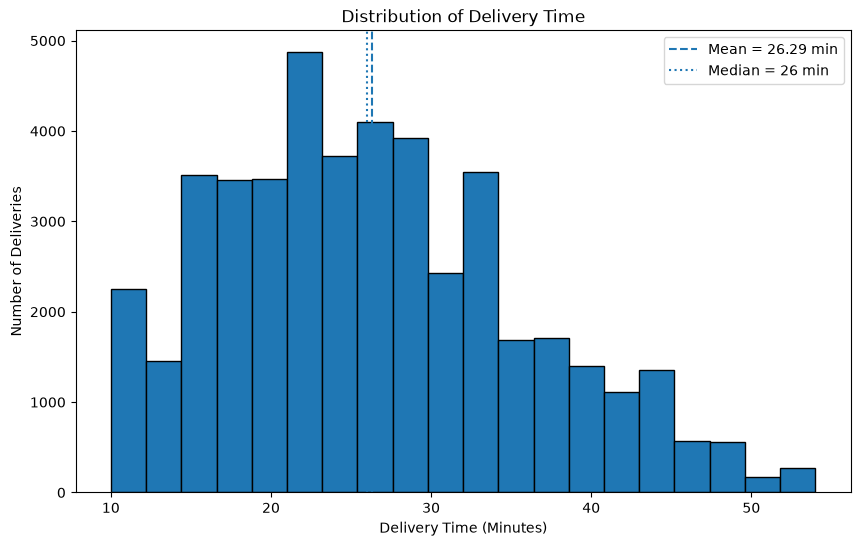

In [8]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["Time_taken (min)"],
    bins=20,
    edgecolor="black"
)

plt.axvline(
    delivery_mean,
    linestyle="--",
    label=f"Mean = {delivery_mean:.2f} min"
)

plt.axvline(
    delivery_median,
    linestyle=":",
    label=f"Median = {delivery_median:.0f} min"
)

plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (Minutes)")
plt.ylabel("Number of Deliveries")
plt.legend()

plt.show()

In [9]:
traffic_analysis = (
    df.groupby("Road_traffic_density")["Time_taken (min)"]
      .agg(["count", "mean", "median"])
      .round(2)
      .sort_values("mean")
)

traffic_analysis

,count,mean,median
Road_traffic_density,,,
Low,15476,21.27,20.0
Unknown,601,26.54,26.0
Medium,10945,26.70,27.0
High,4423,27.24,27.0
Jam,14139,31.18,31.0


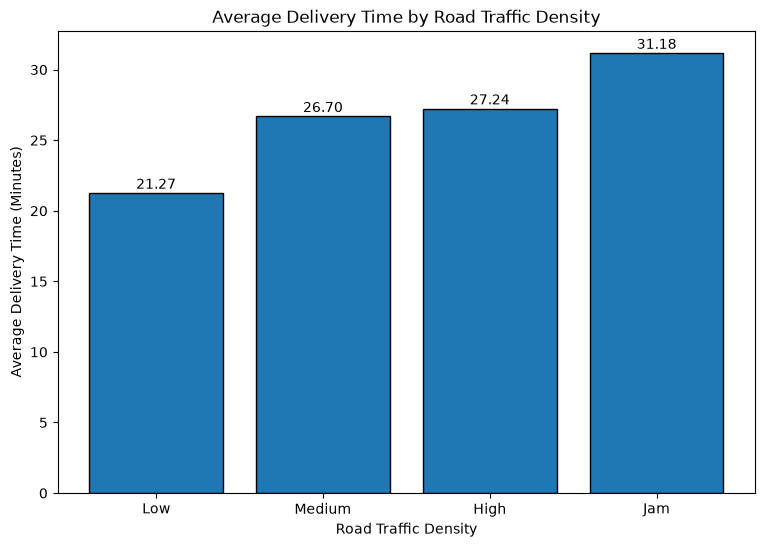

In [10]:
traffic_order = ["Low", "Medium", "High", "Jam"]

traffic_avg = (
    df[df["Road_traffic_density"].isin(traffic_order)]
    .groupby("Road_traffic_density")["Time_taken (min)"]
    .mean()
    .reindex(traffic_order)
)

plt.figure(figsize=(9, 6))

bars = plt.bar(
    traffic_avg.index,
    traffic_avg.values,
    edgecolor="black"
)

plt.title("Average Delivery Time by Road Traffic Density")
plt.xlabel("Road Traffic Density")
plt.ylabel("Average Delivery Time (Minutes)")

for bar, value in zip(bars, traffic_avg.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.3,
        f"{value:.2f}",
        ha="center"
    )

plt.show()

In [11]:
weather_analysis = (
    df.groupby("Weather_conditions")["Time_taken (min)"]
      .agg(["count", "mean", "median"])
      .round(2)
      .sort_values("mean")
)

weather_analysis

,count,mean,median
Weather_conditions,,,
Sunny,7282,21.86,20.0
Stormy,7584,25.87,26.0
Sandstorms,7494,25.88,26.0
Windy,7422,26.12,26.0
Unknown,616,26.55,26.0
Fog,7653,28.91,28.0
Cloudy,7533,28.92,28.0


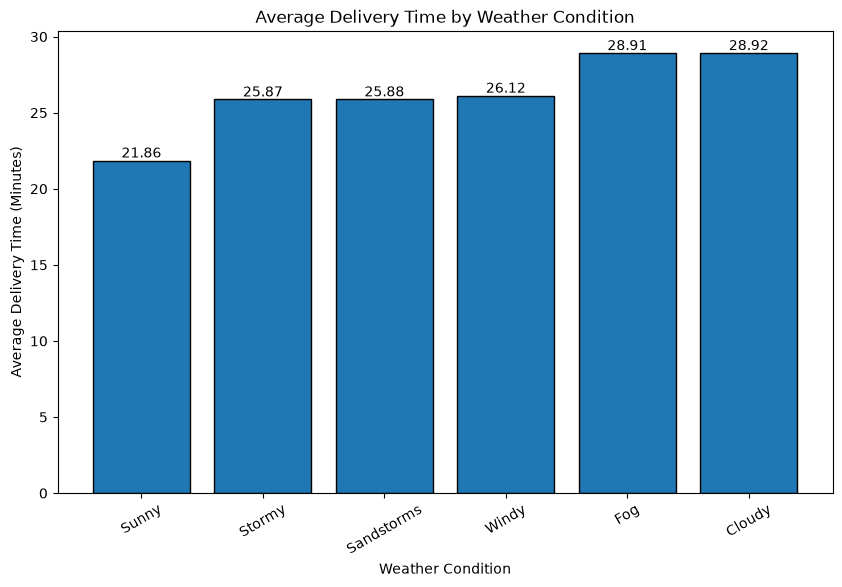

In [12]:
weather_avg = (
    df[df["Weather_conditions"] != "Unknown"]
    .groupby("Weather_conditions")["Time_taken (min)"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    weather_avg.index,
    weather_avg.values,
    edgecolor="black"
)

plt.title("Average Delivery Time by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Average Delivery Time (Minutes)")

for bar, value in zip(bars, weather_avg.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.2,
        f"{value:.2f}",
        ha="center"
    )

plt.xticks(rotation=30)
plt.show()

In [13]:
multiple_delivery_analysis = (
    df.groupby("multiple_deliveries")["Time_taken (min)"]
      .agg(["count", "mean", "median"])
      .round(2)
      .sort_index()
)

multiple_delivery_analysis

,count,mean,median
multiple_deliveries,,,
0.0,14094,22.88,22.0
1.0,29144,26.72,26.0
2.0,1985,40.45,40.0
3.0,361,47.82,48.0


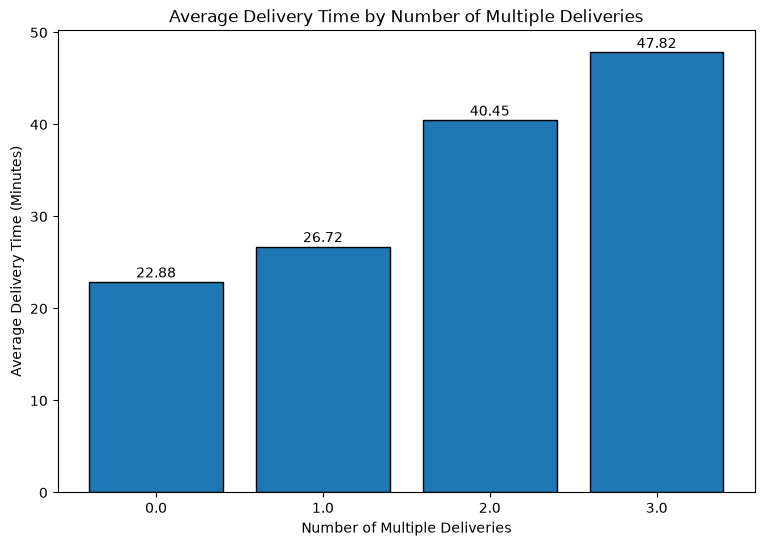

In [14]:
multiple_avg = (
    df.groupby("multiple_deliveries")["Time_taken (min)"]
      .mean()
      .sort_index()
)

plt.figure(figsize=(9, 6))

bars = plt.bar(
    multiple_avg.index.astype(str),
    multiple_avg.values,
    edgecolor="black"
)

plt.title("Average Delivery Time by Number of Multiple Deliveries")
plt.xlabel("Number of Multiple Deliveries")
plt.ylabel("Average Delivery Time (Minutes)")

for bar, value in zip(bars, multiple_avg.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.5,
        f"{value:.2f}",
        ha="center"
    )

plt.show()

In [15]:
festival_analysis = (
    df.groupby("Festival")["Time_taken (min)"]
      .agg(["count", "mean", "median"])
      .round(2)
      .sort_values("mean")
)

festival_analysis

,count,mean,median
Festival,,,
Unknown,228,11.17,11.0
No,44460,25.98,25.0
Yes,896,45.52,45.0


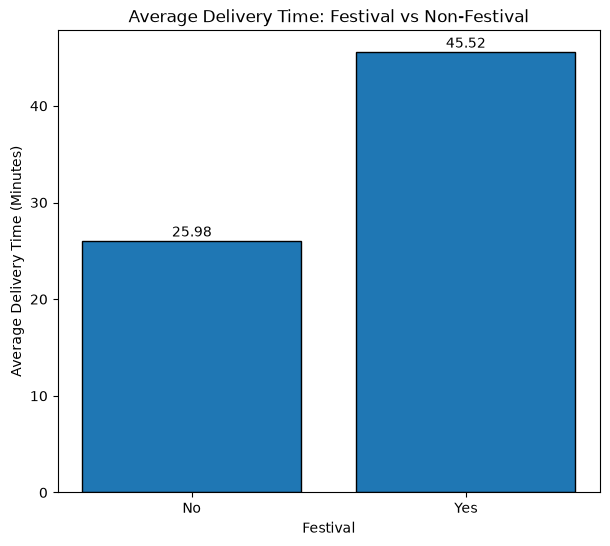

In [16]:
festival_avg = (
    df[df["Festival"].isin(["No", "Yes"])]
    .groupby("Festival")["Time_taken (min)"]
    .mean()
    .reindex(["No", "Yes"])
)

plt.figure(figsize=(7, 6))

bars = plt.bar(
    festival_avg.index,
    festival_avg.values,
    edgecolor="black"
)

plt.title("Average Delivery Time: Festival vs Non-Festival")
plt.xlabel("Festival")
plt.ylabel("Average Delivery Time (Minutes)")

for bar, value in zip(bars, festival_avg.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.5,
        f"{value:.2f}",
        ha="center"
    )

plt.show()

In [17]:
numeric_cols = [
    "Delivery_person_Age",
    "Delivery_person_Ratings",
    "Vehicle_condition",
    "multiple_deliveries",
    "Pickup_Delay_Minutes",
    "Time_taken (min)"
]

correlation_matrix = df[numeric_cols].corr()

correlation_matrix.round(2)

,Delivery_person_Age,Delivery_person_Ratings,Vehicle_condition,multiple_deliveries,Pickup_Delay_Minutes,Time_taken (min)
Delivery_person_Age,1.00,-0.09,0.01,0.11,-0.01,0.29
Delivery_person_Ratings,-0.09,1.00,0.03,-0.12,0.00,-0.34
Vehicle_condition,0.01,0.03,1.00,-0.10,0.01,-0.23
multiple_deliveries,0.11,-0.12,-0.10,1.00,-0.00,0.38
Pickup_Delay_Minutes,-0.01,0.00,0.01,-0.00,1.00,-0.01
Time_taken (min),0.29,-0.34,-0.23,0.38,-0.01,1.00


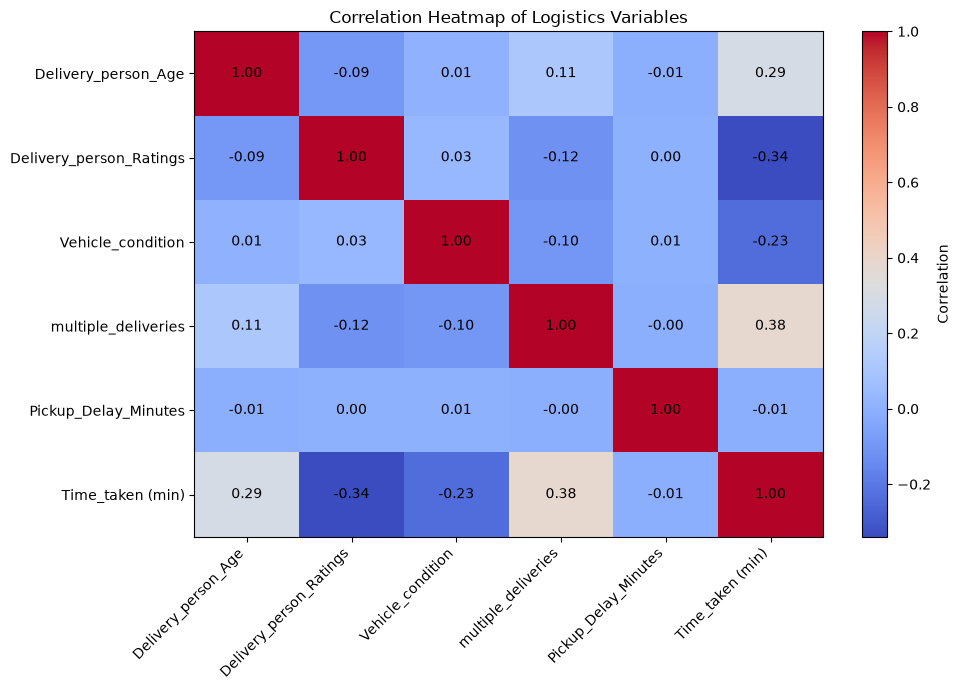

In [18]:
plt.figure(figsize=(10, 7))

plt.imshow(correlation_matrix, cmap="coolwarm", aspect="auto")

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.index)),
    correlation_matrix.index
)

for i in range(len(correlation_matrix.index)):
    for j in range(len(correlation_matrix.columns)):
        plt.text(
            j, i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Correlation Heatmap of Logistics Variables")
plt.tight_layout()
plt.show()

In [19]:
ratings_analysis = (
    df.groupby("Delivery_person_Ratings")["Time_taken (min)"]
      .agg(["count", "mean", "median"])
      .round(2)
      .sort_index()
)

ratings_analysis

,count,mean,median
Delivery_person_Ratings,,,
1.0,38,26.00,26.5
2.5,20,37.30,35.5
2.6,22,38.59,39.0
2.7,22,35.86,36.5
2.8,19,36.63,37.0
2.9,19,38.53,39.0
3.0,6,32.67,32.5
3.1,29,36.55,35.0
3.2,29,36.34,36.0


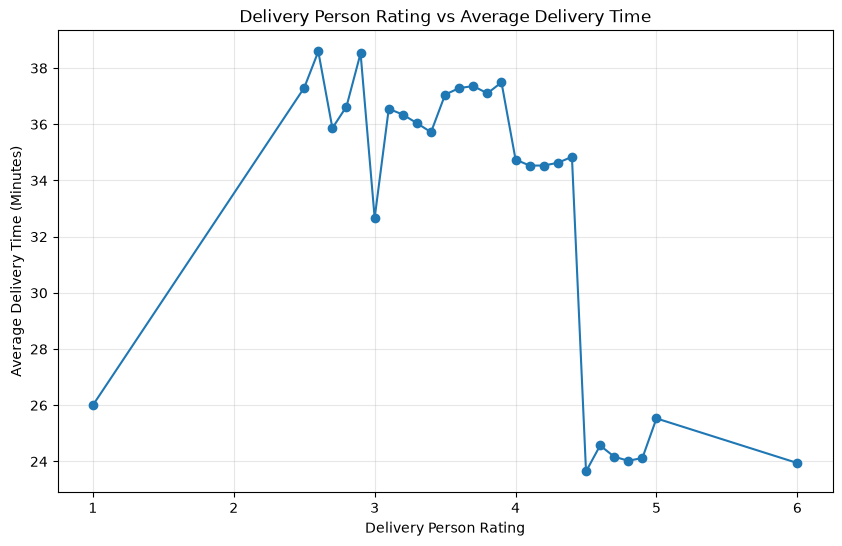

In [20]:
rating_avg = (
    df.groupby("Delivery_person_Ratings")["Time_taken (min)"]
      .mean()
      .sort_index()
)

plt.figure(figsize=(10, 6))

plt.plot(
    rating_avg.index,
    rating_avg.values,
    marker="o"
)

plt.title("Delivery Person Rating vs Average Delivery Time")
plt.xlabel("Delivery Person Rating")
plt.ylabel("Average Delivery Time (Minutes)")
plt.grid(alpha=0.3)

plt.show()

In [21]:
vehicle_analysis = (
    df.groupby("Vehicle_condition")["Time_taken (min)"]
      .agg(["count", "mean", "median"])
      .round(2)
      .sort_index()
)

vehicle_analysis

,count,mean,median
Vehicle_condition,,,
0,15005,30.07,28.0
1,15028,24.35,24.0
2,15031,24.45,24.0
3,520,26.49,26.0


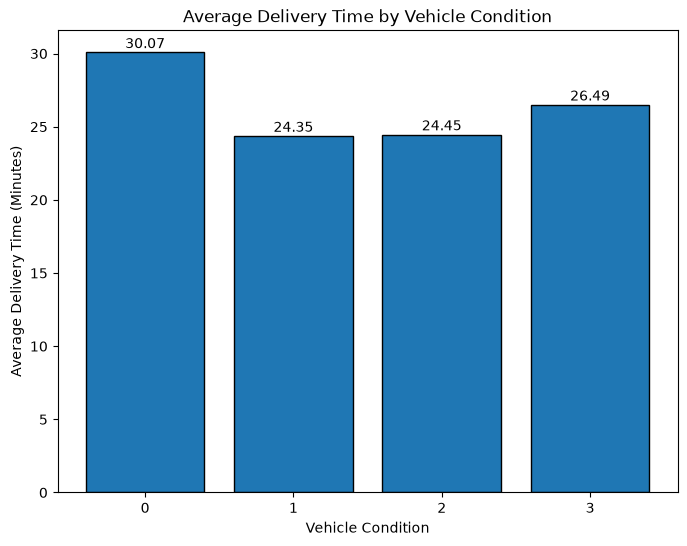

In [22]:
vehicle_avg = (
    df.groupby("Vehicle_condition")["Time_taken (min)"]
      .mean()
      .sort_index()
)

plt.figure(figsize=(8, 6))

bars = plt.bar(
    vehicle_avg.index.astype(str),
    vehicle_avg.values,
    edgecolor="black"
)

plt.title("Average Delivery Time by Vehicle Condition")
plt.xlabel("Vehicle Condition")
plt.ylabel("Average Delivery Time (Minutes)")

for bar, value in zip(bars, vehicle_avg.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.3,
        f"{value:.2f}",
        ha="center"
    )

plt.show()

## Key Findings and Operational Insights

1. **Overall Delivery Performance**
   - The average delivery time is approximately 26.29 minutes.
   - The median and mode are both 26 minutes, indicating that a typical delivery takes around 26 minutes.

2. **Impact of Road Traffic**
   - Average delivery time increases from 21.27 minutes under low traffic to 31.18 minutes during traffic jams.
   - Traffic congestion is therefore strongly associated with slower delivery performance.

3. **Impact of Weather**
   - Sunny weather has the lowest average delivery time at 21.86 minutes.
   - Foggy and cloudy conditions show the highest average delivery times at approximately 28.91 and 28.92 minutes.

4. **Multiple Deliveries**
   - Delivery time rises substantially as the number of multiple deliveries increases.
   - Average delivery time increases from 22.88 minutes for zero multiple deliveries to 47.82 minutes for three multiple deliveries.
   - Multiple deliveries also show the strongest positive correlation with delivery time among the selected numerical variables (0.38).

5. **Festival Deliveries**
   - Non-festival deliveries average 25.98 minutes, compared with 45.52 minutes during festivals.
   - Festival periods are associated with substantially longer delivery times.

6. **Delivery Person Ratings**
   - Delivery person rating has a negative correlation (-0.34) with delivery time.
   - Higher ratings are generally associated with shorter delivery times, although the rating-wise pattern is not perfectly linear.

7. **Vehicle Condition**
   - Vehicle condition shows a weak negative correlation (-0.23) with delivery time.
   - Vehicle condition 0 records have the highest average delivery time at 30.07 minutes.
   - The relationship is not strictly linear across all vehicle-condition categories.

## Operational Recommendations

- Improve route planning and delivery allocation during heavy traffic.
- Avoid assigning excessive simultaneous deliveries to a single delivery person.
- Increase operational capacity during festival periods.
- Account for adverse weather conditions when estimating delivery times.
- Monitor vehicle condition and maintain delivery vehicles regularly.
- Study the practices of higher-rated delivery personnel to identify potential efficiency improvements.

## Analysis Note

The relationships identified in this exploratory analysis represent associations and should not automatically be interpreted as causal effects. Some categories also have unequal sample sizes, which should be considered when interpreting the results.